In [1]:
import pandas as pd
import csv

# Leer el archivo Excel
df = pd.read_excel("train.xlsx")

# Reemplazar saltos de línea en todas las columnas de texto
df = df.applymap(lambda x: str(x).replace("\n", " ") if isinstance(x, str) else x)

# Guardar como CSV
df.to_csv("train_posadas.csv", index=False, encoding="utf-8-sig",quoting=csv.QUOTE_MINIMAL)

# Leer el archivo Excel
df = pd.read_excel("test.xlsx")

# Reemplazar saltos de línea en todas las columnas de texto
df = df.applymap(lambda x: str(x).replace("\n", " ") if isinstance(x, str) else x)

# Guardar como CSV
df.to_csv("test_posadas.csv", index=False, encoding="utf-8-sig",quoting=csv.QUOTE_MINIMAL)

C:\Users\lendg\AppData\Local\Temp\ipykernel_17600\3896776225.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: str(x).replace("\n", " ") if isinstance(x, str) else x)
C:\Users\lendg\AppData\Local\Temp\ipykernel_17600\3896776225.py:17: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: str(x).replace("\n", " ") if isinstance(x, str) else x)


In [2]:
testt = pd.read_csv("test_tretiakov.csv", encoding="utf-8-sig")
testp = pd.read_csv("test_posadas.csv", encoding="utf-8-sig")
trainp = pd.read_csv("train_posadas.csv", encoding="utf-8-sig")

# Mostrar información general de cada dataset
print("=== test_tretiakov ===")
print(testt.info())
#print(testt.head(3))   # primeras 3 filas

print("\n=== test_posadas ===")
print(testp.info())
#print(testg.head(3))

print("\n=== train_posadas ===")
print(trainp.info())
#print(traing.head(3))




=== test_tretiakov ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2552 entries, 0 to 2551
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Topic           2552 non-null   object
 1   Link source     1207 non-null   object
 2   Media           1954 non-null   object
 3   Date            1377 non-null   object
 4   author          912 non-null    object
 5   Headlines       696 non-null    object
 6   Fake statement  2549 non-null   object
dtypes: object(7)
memory usage: 139.7+ KB
None

=== test_posadas ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   ID        572 non-null    int64 
 1   CATEGORY  572 non-null    bool  
 2   TOPICS    572 non-null    object
 3   SOURCE    565 non-null    object
 4   HEADLINE  500 non-null    object
 5   TEXT      572 non-null    objec

In [3]:
# Normalizar nombres de columnas en test/train de posadas
testp.columns = [col.capitalize() for col in testp.columns]
print(testp.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Id        572 non-null    int64 
 1   Category  572 non-null    bool  
 2   Topics    572 non-null    object
 3   Source    565 non-null    object
 4   Headline  500 non-null    object
 5   Text      572 non-null    object
 6   Link      569 non-null    object
dtypes: bool(1), int64(1), object(5)
memory usage: 27.5+ KB
None


In [4]:
# Rango de fechas en Tretiakov

# Convertir la columna Date a datetime (ignora valores nulos o mal formateados)
testt["Date"] = pd.to_datetime(testt["Date"], errors="coerce")

# Ahora se puede calcular el rango de fechas
print("Fecha mínima:", testt["Date"].min())
print("Fecha máxima:", testt["Date"].max())
print("Rango de fechas en Tretiakov:")
print(testt["Date"].min(), "→", testt["Date"].max())

Fecha mínima: 2005-12-15 00:00:00
Fecha máxima: 2021-10-12 00:00:00
Rango de fechas en Tretiakov:
2005-12-15 00:00:00 → 2021-10-12 00:00:00


In [5]:
# Tipos de valores en Topic de Tretiakov
print("\nValores únicos en Topic (Tretiakov):")
print(testt["Topic"].unique())

# Tipos de valores en Topics para test/train de Posadas
print("\nValores únicos en Topics (test_posadas):")
print(testp["Topics"].unique())

print("\nValores únicos en Topics (train_posadas):")
print(trainp["Topic"].unique())


Valores únicos en Topic (Tretiakov):
['Society' 'Politics' 'COVID-19' 'Celebrities' 'Legislation' 'Satirical'
 'Business and economy' 'Science' 'Immigration' 'Religion' 'Terrorism'
 'Sport' 'Sexism' 'LGBTQ' 'Crime' 'Racism' 'Health' 'False alert' 'LGBTQ+'
 'Legalization' 'False advertising' 'ciencia']

Valores únicos en Topics (test_posadas):
['Covid-19' 'Política' 'Sociedad' 'Internacional' 'Ciencia' 'Deporte'
 'Ambiental']

Valores únicos en Topics (train_posadas):
['Education' 'Society' 'Science' 'Security' 'Health' 'Economy' 'Sport'
 'Politics' 'Entertainment']


In [6]:
# Tipos de valores de Category en test/train de Posadas
print("\nValores únicos en Category (test_posadas):")
print(testp["Category"].unique())

print("\nValores únicos en Category (train_posadas):")
print(trainp["Category"].unique())


Valores únicos en Category (test_posadas):
[ True False]

Valores únicos en Category (train_posadas):
['Fake' 'True']


In [7]:
# Cantidad de noticias verdaderas y falsas en test/train de Posadas
print("\nConteo de Category en test_posadas:")
print(testp["Category"].value_counts())

print("\nConteo de Category en train_posadas:")
print(trainp["Category"].value_counts())


Conteo de Category en test_posadas:
Category
True     286
False    286
Name: count, dtype: int64

Conteo de Category en train_posadas:
Category
Fake    338
True    338
Name: count, dtype: int64


In [8]:
# Unificar LGBTQ y LGBTQ+ en Tretiakov
testt["Topic"] = testt["Topic"].replace({"LGBTQ": "LGBTQ+"})


In [9]:
# Diccionario de normalización para Tretiakov
normalize_cols_tretiakov = {
    "Topic": "Topic",
    "Link source": "Link",
    "Media": "Source",
    "Date": "Date",
    "author": "Author",
    "Headlines": "Headline",
    "Fake statement": "Text"
}

# Posadas y Train ya están consistentes, solo asegurar capitalización
normalize_cols_posadas = {
    "Id": "Id",
    "Category": "Category",
    "Topics": "Topic",
    "Source": "Source",
    "Headline": "Headline",
    "Text": "Text",
    "Link": "Link"
}

normalize_cols_train = {
    "Id": "Id",
    "Category": "Category",
    "Topic": "Topic",
    "Source": "Source",
    "Headline": "Headline",
    "Text": "Text",
    "Link": "Link"
}

# Aplicar normalización
testt.rename(columns=normalize_cols_tretiakov, inplace=True)
testp.rename(columns=normalize_cols_posadas, inplace=True)
trainp.rename(columns=normalize_cols_train, inplace=True)

# Verificar
print("=== test_tretiakov ===")
print(testt.columns)
print("=== test_posadas ===")
print(testp.columns)
print("=== train_posadas ===")
print(trainp.columns)


=== test_tretiakov ===
Index(['Topic', 'Link', 'Source', 'Date', 'Author', 'Headline', 'Text'], dtype='object')
=== test_posadas ===
Index(['Id', 'Category', 'Topic', 'Source', 'Headline', 'Text', 'Link'], dtype='object')
=== train_posadas ===
Index(['Id', 'Category', 'Topic', 'Source', 'Headline', 'Text', 'Link'], dtype='object')


In [10]:
# Normalizar Category en train_posadas
# Convertir 'Fake' a False, 'True' a True
trainp["Category"] = trainp["Category"].map({"Fake": False, "True": True})

# Asegurar que test_posadas también sea booleano (por si acaso)
testp["Category"] = testp["Category"].astype(bool)

# Verificar
print("=== test_posadas ===")
print(testp["Category"].value_counts())
print("=== train_posadas ===")
print(trainp["Category"].value_counts())

=== test_posadas ===
Category
True     286
False    286
Name: count, dtype: int64
=== train_posadas ===
Category
False    338
True     338
Name: count, dtype: int64


In [11]:
# Crear versión normalizada de Tretiakov para el corpus
testt_norm = pd.DataFrame({
    "Category": False,  # todas falsas
    "Topic": testt["Topic"],
    "Source": testt["Source"],       # ya normalizado
    "Headline": testt["Headline"],
    "Text": testt["Text"],           # Fake statement => Text
    "Link": testt["Link"]            # Link source => Link
})

# Seleccionar columnas relevantes de Posadas
testp_norm = testp[["Category", "Topic", "Source", "Headline", "Text", "Link"]]
trainp_norm = trainp[["Category", "Topic", "Source", "Headline", "Text", "Link"]]

# Concatenar todo en corpusn
corpusn = pd.concat([testt_norm, testp_norm, trainp_norm], ignore_index=True)

# Verificar
print("=== corpusn ===")
print(corpusn.info())
print(corpusn.head())


=== corpusn ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3800 entries, 0 to 3799
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  3800 non-null   bool  
 1   Topic     3800 non-null   object
 2   Source    3195 non-null   object
 3   Headline  1872 non-null   object
 4   Text      3797 non-null   object
 5   Link      2452 non-null   object
dtypes: bool(1), object(5)
memory usage: 152.3+ KB
None
   Category        Topic      Source  \
0     False      Society  12 Minutos   
1     False     Politics   123ru.net   
2     False     COVID-19   12minutos   
3     False  Celebrities   12minutos   
4     False  Legislation   12minutos   

                                            Headline  \
0                                                NaN   
1  López Obrador insiste con España y pide crear ...   
2                                                NaN   
3               Dylan rechaza el Nobel de Literatura 

In [12]:
# Ver cuántos registros duplicados hay
duplicates_count = corpusn.duplicated().sum()
print(f"Número de registros duplicados: {duplicates_count}")

# Mostrar los registros duplicados (si existen)
duplicates = corpusn[corpusn.duplicated()]
print(duplicates.head())


Número de registros duplicados: 13
      Category        Topic    Source Headline  \
430      False  Celebrities  Facebook      NaN   
634      False     COVID-19  Facebook      NaN   
1269     False  Immigration   Twitter      NaN   
1285     False  Legislation   Twitter      NaN   
1610     False     COVID-19   Twitter      NaN   

                                                   Text  \
430   En este momento, acostado en la cama, enfermo ...   
634   La Junta de Andalucía cierra perimetralmente e...   
1269  diversiones y costumbres de los inmigrantes de...   
1285  En Finlandia están prohibidos los colegios pri...   
1610  Hola, soy Sandra Romero, dni 37263954 Me puse ...   

                                                   Link  
430                                                 NaN  
634                                                 NaN  
1269  https://twitter.com/curiosoooi/status/12165903...  
1285  https://twitter.com/peteom/status/117225951799...  
1610               

In [13]:
# Mostrar pares de duplicados
dupes = corpusn[corpusn.duplicated(keep=False)]
dupes.sort_values(by=list(corpusn.columns)).head(20)


,Category,Topic,Source,Headline,Text,Link
1971,False,Business and economy,NaN,NaN,"¡Si los bancos son listos, seamos nosotros más...",NaN
2277,False,Business and economy,NaN,NaN,"¡Si los bancos son listos, seamos nosotros más...",NaN
412,False,COVID-19,Facebook,NaN,La Junta de Andalucía cierra perimetralmente e...,NaN
634,False,COVID-19,Facebook,NaN,La Junta de Andalucía cierra perimetralmente e...,NaN
1157,False,COVID-19,Twitter,NaN,"Hola, soy Sandra Romero, dni 37263954 Me puse ...",NaN
1610,False,COVID-19,Twitter,NaN,"Hola, soy Sandra Romero, dni 37263954 Me puse ...",NaN
2223,False,COVID-19,NaN,NaN,Bueno voy al gimnasio cada día y considero que...,NaN
2227,False,COVID-19,NaN,NaN,Bueno voy al gimnasio cada día y considero que...,NaN
2024,False,COVID-19,NaN,NaN,más muertes con el coronavirus esto no es norm...,NaN
2167,False,COVID-19,NaN,NaN,más muertes con el coronavirus esto no es norm...,NaN


In [14]:
# Eliminar duplicados y crear una versión limpia
corpusn_clean = corpusn.drop_duplicates().reset_index(drop=True)

# Verificar
print(f"Número de registros en corpusn original: {len(corpusn)}")
print(f"Número de registros en corpusn_clean: {len(corpusn_clean)}")


Número de registros en corpusn original: 3800
Número de registros en corpusn_clean: 3787


In [15]:
# Ver cuántos registros están completamente vacíos
empty_rows = corpusn_clean[["Category","Topic","Source","Headline","Text","Link"]].isnull().all(axis=1).sum()
print(f"Número de registros completamente vacíos: {empty_rows}")

# Mostrar ejemplos de registros vacíos (si existen)
print(corpusn_clean[corpusn_clean[["Category","Topic","Source","Headline","Text","Link"]].isnull().all(axis=1)].head())

# Eliminar registros vacíos y crear corpusn_clean2
#corpusn_clean2 = corpusn[~corpusn[["Category","Topic","Source","Headline","Text","Link"]].isnull().all(axis=1)].reset_index(drop=True)

# Verificar
#print(f"Número de registros después de eliminar vacíos: {len(corpusn_clean2)}")


Número de registros completamente vacíos: 0
Empty DataFrame
Columns: [Category, Topic, Source, Headline, Text, Link]
Index: []


In [16]:
print(corpusn_clean.isnull().sum())

Category       0
Topic          0
Source       598
Headline    1915
Text           3
Link        1337
dtype: int64


In [17]:
# Eliminar registros sin texto (Text nulo)
corpusn_clean = corpusn_clean[corpusn_clean["Text"].notnull()].reset_index(drop=True)

print("Registros después de eliminar los que no tienen texto:", len(corpusn_clean))


Registros después de eliminar los que no tienen texto: 3784


In [18]:
# Revisar cuántos registros siguen sin Headline
print("Registros sin Headline:", corpusn_clean["Headline"].isnull().sum())


Registros sin Headline: 1915


In [19]:
# Crear columna combinada Headline + Text
corpusn_clean["Headline_Text"] = corpusn_clean.apply(
    lambda row: row["Headline"] + " " + row["Text"] if pd.notnull(row["Headline"]) else row["Text"],
    axis=1
)

# Verificar
print(corpusn_clean[["Headline","Text","Headline_Text"]].head())


                                            Headline  \
0                                                NaN   
1  López Obrador insiste con España y pide crear ...   
2                                                NaN   
3               Dylan rechaza el Nobel de Literatura   
4                                                NaN   

                                                Text  \
0  Ingresada una influencer madrileña por hipoter...   
1  El objetivo, afirma, sería “hacer una relatorí...   
2  Inglaterra se sume en el caos” después de que ...   
3  Luego de varios días de infructuosos intentos ...   
4  Los hermanos mayores pagaran 75€ al mes a sus ...   

                                       Headline_Text  
0  Ingresada una influencer madrileña por hipoter...  
1  López Obrador insiste con España y pide crear ...  
2  Inglaterra se sume en el caos” después de que ...  
3  Dylan rechaza el Nobel de Literatura Luego de ...  
4  Los hermanos mayores pagaran 75€ al mes a sus ..

In [20]:
corpusn_clean["Text"].str.len().describe()

count     3784.000000
mean      1237.987844
std       1737.314598
min         23.000000
25%        174.000000
50%        496.500000
75%       1711.250000
max      25764.000000
Name: Text, dtype: float64

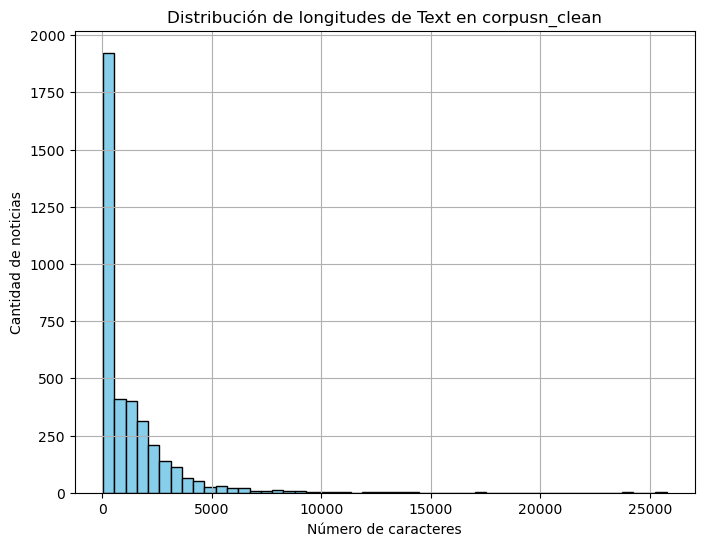

In [21]:
import matplotlib.pyplot as plt

# Histograma de longitudes de Text
plt.figure(figsize=(8,6))
corpusn_clean["Text"].str.len().hist(bins=50, color="skyblue", edgecolor="black")
plt.title("Distribución de longitudes de Text en corpusn_clean")
plt.xlabel("Número de caracteres")
plt.ylabel("Cantidad de noticias")

# Guardar imagen en PNG con buena resolución
plt.savefig("histograma_longitudes_text.png", dpi=300)

# Mostrar gráfico
plt.show()


In [22]:
# Calcular longitudes de cada texto
text_lengths = corpusn_clean["Text"].str.len()

# Contar cuántos textos tienen 100 caracteres o menos
short_texts_count = (text_lengths <= 100).sum()

print("Cantidad de textos con 100 caracteres o menos:", short_texts_count)

# Ver ejemplos de esos textos
short_texts_examples = corpusn_clean[text_lengths <= 100]["Text"].head(10)
print("\nEjemplos de textos cortos:\n", short_texts_examples)


Cantidad de textos con 100 caracteres o menos: 375

Ejemplos de textos cortos:
 0      Ingresada una influencer madrileña por hipoter...
4      Los hermanos mayores pagaran 75€ al mes a sus ...
13     Se repetirá el día 26 de diciembre el sorteo d...
24     Pedro Cavadas: "prefiero morir del 'covid' que...
26     El fiscal de menores de Andalucía propone elim...
55     Si el Estado Islámico ‘degolla’ niños en Irak ...
71                 Los Simpson lo predijeron, nuevamente
72     Escándalo de Salvador Illa: ¡pone la bandera d...
113    Cáritas rechaza ayudar a una mujer española po...
116    Prohibido comer JAMON en un colegio de Terrass...
Name: Text, dtype: object


In [23]:
# Filtrar registros con más de 100 caracteres en Text
corpusn_clean = corpusn_clean[corpusn_clean["Text"].str.len() > 100].reset_index(drop=True)

# Verificar resultado
print("Cantidad de registros después del filtrado:", len(corpusn_clean))
print("Cantidad de textos con <=100 caracteres:", (corpusn_clean["Text"].str.len() <= 100).sum())

Cantidad de registros después del filtrado: 3409
Cantidad de textos con <=100 caracteres: 0


In [24]:
# Calcular longitudes de cada texto
text_lengths = corpusn_clean["Text"].str.len()

# Obtener los índices de los 2 textos más largos
top2_indices = text_lengths.nlargest(2).index

# Mostrar claramente los textos más largos
for i, idx in enumerate(top2_indices, start=1):
    print(f"\n--- Texto más largo #{i} (longitud: {text_lengths[idx]} caracteres) ---\n")
    print(corpusn_clean.loc[idx, "Text"])



--- Texto más largo #1 (longitud: 25764 caracteres) ---

En el informe “Informed Consent Disclosure to Vaccine Trial Subjects of Risk of COVID-19 Vaccine Worstering Clinical Disease“, publicado en el International Journal of Clinical Practice el 28 de octubre de 2020, se señala que “las vacunas COVID-19 diseñadas para inducir anticuerpos neutralizantes pueden sensibilizar a los receptores de la vacuna a una enfermedad más grave que si no estuvieran vacunados”.  Según el estudio:  “Las vacunas contra el SARS, el MERS y el RSV nunca han sido autorizadas y los datos obtenidos durante el desarrollo y las pruebas de estas vacunas indican una seria preocupación: Que las vacunas desarrolladas empíricamente utilizando el enfoque tradicional (consistente en la espiga del coronavirus no modificada o mínimamente modificada que produce anticuerpos neutralizantes), ya sea que estén hechas de proteína, vector viral, ADN o ARN, e independientemente del método de administración, pueden agravar la enf

In [25]:
# Calcular longitudes de cada texto
text_lengths = corpusn_clean["Text"].str.len()

# Filtrar textos muy largos (ejemplo: >= 10000 caracteres)
long_texts = corpusn_clean[text_lengths >= 10000].copy()

# Agregar columna con longitud
long_texts["Longitud"] = text_lengths[text_lengths >= 10000]

# Mostrar índice, categoría y longitud
print("\nÍndice, categoría y longitud de los textos largos:")
print(long_texts[["Category", "Longitud"]])

# Mostrar conteo de categorías (True vs False)
print("\nDistribución de categorías en textos largos:")
print(long_texts["Category"].value_counts())



Índice, categoría y longitud de los textos largos:
      Category  Longitud
2189      True     10549
2207      True     12013
2241     False     13404
2286     False     25764
2324     False     17242
2381     False     12502
2412     False     13647
2467      True     14019
2470      True     10167
2550      True     11343
2573     False     11941
2658      True     23951
2741      True     11168
2867     False     10035
2946      True     10301
3142      True     12403
3222      True     12437

Distribución de categorías en textos largos:
Category
True     10
False     7
Name: count, dtype: int64


In [26]:
# Normalizar columnas categóricas: Topic y Source
corpusn_clean["Topic"] = corpusn_clean["Topic"].str.strip().str.lower().str.title()
corpusn_clean["Source"] = corpusn_clean["Source"].str.strip().str.lower().str.title()

# Verificar valores únicos después de la normalización
print("Valores únicos en Topic después de normalización:")
print(corpusn_clean["Topic"].unique())

print("\nValores únicos en Source después de normalización:")
print(corpusn_clean["Source"].unique())


Valores únicos en Topic después de normalización:
['Politics' 'Covid-19' 'Celebrities' 'Satirical' 'Business And Economy'
 'Science' 'Immigration' 'Religion' 'Terrorism' 'Sport' 'Society' 'Sexism'
 'Crime' 'Legislation' 'Racism' 'Lgbtq+' 'Health' 'False Alert'
 'Legalization' 'Política' 'Sociedad' 'Internacional' 'Ciencia' 'Deporte'
 'Ambiental' 'Education' 'Security' 'Economy' 'Entertainment']

Valores únicos en Source después de normalización:
['123Ru.Net' '12Minutos' '20Minutos' '25Minutos' 'Abc'
 'Acontecer Cristiano' 'Actualidad.Rt' 'Actuall' 'Ahora' 'Alerta Digital'
 'Alerta Digital Y Alerta Nacional' 'Alerta Nacional' 'Altera Digital'
 'America.Periodistadigital' 'Andorranotícies' 'Anonymousweb' 'Antena 3'
 'As.Com' 'Asociacion De Militares Españoles' 'Autofácil'
 'Bibliatodo Noticias' 'Bioguia.Es' 'Blogpost' 'Blogspot' 'Burbuja'
 'Cabronews' 'Casoaislado' 'Catalunyapress' 'Cerebrother' 'Clarin'
 'Club-Caza' 'Cnbc' 'Cnn' 'Computerhoy' 'Conclusion' 'Conocer Salud'
 'Contrainforma

In [27]:
# Diccionario de mapeo de categorías en inglés a español
topic_mapping_es = {
    "Politics": "Política",
    "Covid-19": "Covid-19",
    "Celebrities": "Celebridades",
    "Satirical": "Satírico",
    "Business And Economy": "Economía",
    "Science": "Ciencia",
    "Immigration": "Inmigración",
    "Religion": "Religión",
    "Terrorism": "Terrorismo",
    "Sport": "Deporte",
    "Society": "Sociedad",
    "Sexism": "Sexismo",
    "Crime": "Crimen",
    "Legislation": "Legislación",
    "Racism": "Racismo",
    "Lgbtq+": "LGBTQ+",
    "Lgbtq": "LGBTQ+",
    "Health": "Salud",
    "False Alert": "Alerta Falsa",
    "Legalization": "Legalización",
    "Education": "Educación",
    "Security": "Seguridad",
    "Economy": "Economía",
    "Entertainment": "Entretenimiento",
    "Environment": "Ambiental",
    "International": "Internacional"
}

# Normalizar columna Topic a español
corpusn_clean["Topic"] = corpusn_clean["Topic"].replace(topic_mapping_es)

# Verificar valores únicos después de la consolidación
print("Valores únicos en Topic después de consolidación a español:")
print(sorted(corpusn_clean["Topic"].unique()))


Valores únicos en Topic después de consolidación a español:
['Alerta Falsa', 'Ambiental', 'Celebridades', 'Ciencia', 'Covid-19', 'Crimen', 'Deporte', 'Economía', 'Educación', 'Entretenimiento', 'Inmigración', 'Internacional', 'LGBTQ+', 'Legalización', 'Legislación', 'Política', 'Racismo', 'Religión', 'Salud', 'Satírico', 'Seguridad', 'Sexismo', 'Sociedad', 'Terrorismo']


In [28]:
# Diccionario maestro para normalizar y consolidar fuentes duplicadas
source_mapping_master = {
    "Elpais": "El País",
    "El Paìs": "El País",
    "El Pais": "El País",
    "El Mundo Today.": "El Mundo Today",
    "Larazon": "La Razón",
    "La Razon": "La Razón",
    "Razon": "La Razón",
    "Elconfidencial": "El Confidencial",
    "Elconfidencialdigital": "El Confidencial",
    "Lavanguardia": "La Vanguardia",
    "Lavanguardia.Es": "La Vanguardia",
    "Vanguardia": "La Vanguardia",
    "Lavozdelbecario": "La Voz Del Becario",
    "La Voz Del Bercario": "La Voz Del Becario",
    "Okdiario": "Ok Diario",
    "Cnn": "CNN",
    "Cnn Español": "CNN",
    "Cnn En Español": "CNN",
    "Cnnespañol": "CNN",
    "Bbc": "BBC",
    "Bbc News": "BBC",
    "Dw": "DW",
    "Dw Made For Minds": "DW",
    "France24": "France 24",
    "Facebook Unico Noticias": "Facebook",
    "Facebook /El Señor López": "Facebook",
    "Twitter-Simmsa": "Twitter",
    "Twitter - Calderon": "Twitter",
    "Twitter-Rafael Ramirez": "Twitter",
    "Twitter-Calderon": "Twitter",
    "Twitter -Ricardo Aleman": "Twitter",
    "Whastapp": "Whatsapp",
    "Cronica Directo": "Crónica Directo",
    "Ramblalibre": "Rambla Libre",
    "Expansion": "Expansión",
    "Libertaddigital": "Libertad Digital",
    "Losreplicantes": "Los Replicantes",
    "Animal Politico": "Animal Político",
    "12Minutos": "12 Minutos",
    "20Minutos": "20 Minutos",
    "Casoaislado": "Caso Aislado",
    "Eldiario": "El Diario",
    "Elcorreo": "El Correo",
    "Elcorreodemadrid": "El Correo",
    "Elmatinal": "El Matinal",
    "Elmunicipio": "El Municipio",
    "Elmunicipio.": "El Municipio",
    "Elmunicipio.Es": "El Municipio",
    "Elperiodico": "El Periódico",
    "El Periodico": "El Periódico",
    "Elperiodicodearagon.Com": "El Periódico",
    "Elplural.Com": "El Plural",
    "Esdiario": "Es Diario",
    "Europapress": "Europa Press",
    "La Nacion": "La Nación",
    "La Nacion Digital": "La Nación",
    "La Republica": "La República",
    "Clarin": "Clarín",
    "El Clarin": "Clarín",
    "Eluniverso": "El Universo",
    "Marca.Com": "Marca",
    "La Gaseta": "La Gaceta",
    "Sdpnoticias": "SDP Noticias",
    "Sdp Noticia": "SDP Noticias",
    "Sdp Noticias": "SDP Noticias",
    "Taringa!": "Taringa",
    "Tiempo Digital.Mx": "Tiempo Digital",
    "Redaccion Medica": "Redacción Médica"
}

# Aplicar reemplazo en la columna Source
corpusn_clean["Source"] = corpusn_clean["Source"].replace(source_mapping_master)

# Verificar valores únicos después de la consolidación final
print("Valores únicos en Source después de consolidación final:")
print(sorted(corpusn_clean["Source"].dropna().unique()))


Valores únicos en Source después de consolidación final:
['12 Minutos', '123Ru.Net', '20 Minutos', '2020 News', '25Minutos', 'Aarp', 'Abc', 'Abc Noticias', 'Abc Sociedad', 'Acontecer Cristiano', 'Actualidad', 'Actualidad.Rt', 'Actuall', 'Adn 40', 'Aemps', 'Afpfactual', 'Agencia Efe', 'Ahora', 'Alerta Digital', 'Alerta Digital Y Alerta Nacional', 'Alerta Nacional', 'Altera Digital', 'Am De Queretaro', 'America.Periodistadigital', 'Andoc', 'Andorranotícies', 'Animal Político', 'Anonymous  Azteca', 'Anonymousweb', 'Antena 3', 'Argumento Político', 'Aristegui Noticias', 'As', 'As Epika', 'As.Com', 'Asociacion De Militares Españoles', 'Astillas De Realidad', 'Asuntoslegales', 'Autofácil', 'Avcnoticia', 'Azteca Deporte', 'BBC', 'Bibliatodo Noticias', 'Bioguia.Es', 'Bladi', 'Blogpost', 'Blogspot', 'Bluradio', 'Burbuja', 'Business Insider', 'CNN', 'Cabronews', 'Caracol', 'Caracol Radio', 'Caras', 'Carlosagaton.Blogspot.Com', 'Caso Aislado', 'Catalunyapress', 'Censura 0', 'Centros Para El Contr

In [29]:
# Frecuencia de cada categoría en Topic
topic_counts = corpusn_clean["Topic"].value_counts()

print("Distribución de Topic:")
print(topic_counts)

# Frecuencia de cada categoría en Source
source_counts = corpusn_clean["Source"].value_counts()

print("\nDistribución de Source:")
print(source_counts)

# Opcional: filtrar clases raras (ejemplo: menos de 5 ocurrencias)
rare_topics = topic_counts[topic_counts < 5]
rare_sources = source_counts[source_counts < 5]

print("\nTopics raros (menos de 5 ocurrencias):")
print(rare_topics)

print("\nSources raros (menos de 5 ocurrencias):")
print(rare_sources)


Distribución de Topic:
Topic
Política           886
Covid-19           722
Sociedad           515
Inmigración        204
Ciencia            166
Religión           131
Entretenimiento    103
Sexismo            100
Deporte             98
Economía            87
Alerta Falsa        68
Crimen              62
Celebridades        46
Legislación         42
Salud               35
LGBTQ+              33
Seguridad           29
Racismo             24
Terrorismo          16
Educación           15
Internacional       14
Satírico             7
Ambiental            4
Legalización         2
Name: count, dtype: int64

Distribución de Source:
Source
Twitter                  473
Facebook                 270
Whatsapp                 259
El Dizque                107
Afpfactual                90
                        ... 
Noticias De Catalunya      1
Noticialibre               1
Noticiacristiana           1
Noticia Cristiana          1
Radio Formula              1
Name: count, Length: 494, dtype: int64

To

Se absorvió Environment en Science y Legalization en Politics, ya que eran muy pocos casos como para ser su propia categoría (no aporta al aprendizaje en ningún caso posible). Source se dejó porque no parece haber mayor significancia ni influencia si no se usa como feature o elemento predictivo.

In [30]:
# Diccionario de fusión para Topic raros (en español)
topic_fusion_es = {
    "Ambiental": "Ciencia",       
    "Legalización": "Política"   
}

# Aplicar reemplazo en la columna Topic
corpusn_clean["Topic"] = corpusn_clean["Topic"].replace(topic_fusion_es)

# Verificar distribución final de Topic
print("Distribución de Topic después de fusión de categorías raras (en español):")
print(corpusn_clean["Topic"].value_counts())


Distribución de Topic después de fusión de categorías raras (en español):
Topic
Política           888
Covid-19           722
Sociedad           515
Inmigración        204
Ciencia            170
Religión           131
Entretenimiento    103
Sexismo            100
Deporte             98
Economía            87
Alerta Falsa        68
Crimen              62
Celebridades        46
Legislación         42
Salud               35
LGBTQ+              33
Seguridad           29
Racismo             24
Terrorismo          16
Educación           15
Internacional       14
Satírico             7
Name: count, dtype: int64


In [31]:
# Agrupar por columna Text y contar ocurrencias
text_counts = corpusn_clean.groupby("Text").size()

# Filtrar textos que aparecen más de una vez
duplicate_texts = text_counts[text_counts > 1]

print("Textos duplicados parcialmente (más de una ocurrencia):")
print(duplicate_texts)

# Opcional: mostrar ejemplos de registros con mismo Text pero distinto Link
partial_duplicates = corpusn_clean[corpusn_clean["Text"].isin(duplicate_texts.index)]
partial_duplicates = partial_duplicates.sort_values("Text")

print("\nEjemplos de duplicados parciales (mismo Text, distinto Link):")
print(partial_duplicates[["Text", "Link"]].head(20))


Textos duplicados parcialmente (más de una ocurrencia):
Text
Abuso de autoridad con ensañamiento, en este caso a una señora de 80 años, esto no sale en las noticias, no le interesa al Gobierno.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       

In [32]:
# Guardar tamaño inicial
original_size = len(corpusn_clean)

# Eliminar duplicados parciales: mismo Text, conservar solo la primera ocurrencia
corpusn_clean_no_partial = corpusn_clean.drop_duplicates(subset=["Text"], keep="first")

# Verificar tamaño antes y después
print("Registros originales:", original_size)
print("Registros después de eliminar duplicados parciales:", len(corpusn_clean_no_partial))

# Revisar ejemplos de duplicados eliminados (solo las segundas ocurrencias)
removed = corpusn_clean[corpusn_clean["Text"].duplicated(keep="first")]
print("\nEjemplos de duplicados eliminados:")
print(removed[["Text", "Source", "Link"]].head(10))



Registros originales: 3409
Registros después de eliminar duplicados parciales: 3388

Ejemplos de duplicados eliminados:
                                                   Text        Source  \
369   Abuso de autoridad con ensañamiento, en este c...      Facebook   
659   Cinco días después del arranque del Mundial ha...      La Sexta   
819   Después de que decenas de miles de personas sa...  Noticialibre   
889   Jose Santos es un joven camarero que trabaja e...   Revistazero   
1060  Espero que este tweet no pase desapercibido. P...       Twitter   
1168  un COITO de 2 minutos es más que suficiente pa...       Twitter   
1257  JULIO ANGUITA: "El que debería estar en la cár...       Twitter   
1336  Son días duros, el calor aprieta. Os quiero co...       Twitter   
1351  Los Alcázares ( Murcia) Curso escolar 2019/ 20...       Twitter   
1369  Este es el peligro de la extrema izquierda. Bi...       Twitter   

                                                   Link  
369               

In [33]:
# Al final, reasignar a corpusn_clean para que quede limpio
corpusn_clean = corpusn_clean_no_partial.reset_index(drop=True)


In [34]:
print(corpusn_clean.isnull().sum())


Category            0
Topic               0
Source            459
Headline         1541
Text                0
Link             1064
Headline_Text       0
dtype: int64


In [35]:
print(corpusn_clean["Topic"].value_counts())


Topic
Política           884
Covid-19           718
Sociedad           510
Inmigración        204
Ciencia            169
Religión           128
Entretenimiento    103
Sexismo            100
Deporte             98
Economía            87
Alerta Falsa        68
Crimen              58
Celebridades        46
Legislación         42
Salud               35
LGBTQ+              33
Seguridad           29
Racismo             24
Terrorismo          16
Educación           15
Internacional       14
Satírico             7
Name: count, dtype: int64


In [36]:
print(corpusn_clean["Text"].duplicated().sum())

0


In [37]:
corpusn_clean["Text_length"] = corpusn_clean["Text"].str.len()
print(corpusn_clean["Text_length"].describe())
print(corpusn_clean[corpusn_clean["Text_length"] < 10][["Text","Source"]].head())


count     3388.000000
mean      1372.452774
std       1787.875030
min        101.000000
25%        227.000000
50%        752.500000
75%       1880.250000
max      25764.000000
Name: Text_length, dtype: float64
Empty DataFrame
Columns: [Text, Source]
Index: []


In [38]:
import pandas as pd

# Crear columna que indica si el texto comienza con el titular
corpusn_clean["headline_in_text"] = corpusn_clean.apply(
    lambda row: str(row["Text"]).startswith(str(row["Headline"])) if pd.notnull(row["Headline"]) else False,
    axis=1
)

# Ver cuántos casos tienen redundancia
print(corpusn_clean["headline_in_text"].value_counts())


headline_in_text
False    2711
True      677
Name: count, dtype: int64


In [39]:
import pandas as pd

# Función para limpiar los casos donde el titular está al inicio del texto
def limpiar_headline_in_text(df):
    # Solo aplicar a filas donde headline_in_text es True
    mask = df["headline_in_text"] == True
    
    # Reemplazar Headline_Text con el contenido de Text
    df.loc[mask, "Headline_Text"] = df.loc[mask, "Text"]
    
    # En Text, eliminar el titular al inicio
    df.loc[mask, "Text"] = df.loc[mask].apply(
        lambda row: row["Text"][len(str(row["Headline"])):].lstrip()
        if pd.notnull(row["Headline"]) else row["Text"],
        axis=1
    )
    
    # Eliminar la columna auxiliar
    df = df.drop(columns=["headline_in_text"])
    
    return df

# Aplicar la limpieza
corpusn_clean = limpiar_headline_in_text(corpusn_clean)

# Verificación rápida
print(corpusn_clean.head())


   Category         Topic      Source  \
0     False      Política   123Ru.Net   
1     False      Covid-19  12 Minutos   
2     False  Celebridades  12 Minutos   
3     False      Política  12 Minutos   
4     False      Política  12 Minutos   

                                            Headline  \
0  López Obrador insiste con España y pide crear ...   
1                                                NaN   
2               Dylan rechaza el Nobel de Literatura   
3  Vuelve el Servicio militar obligatorio para me...   
4  OTAN Prepara sus tropas para una posible inter...   

                                                Text  \
0  El objetivo, afirma, sería “hacer una relatorí...   
1  Inglaterra se sume en el caos” después de que ...   
2  Luego de varios días de infructuosos intentos ...   
3  Hoy se ha firmado en Moncloa la vuelta de la '...   
4  El Teniente General del Ejército de Tierra Fer...   

                                                Link  \
0               https:/

Cantidad de noticias verdaderas (True): 624
Cantidad de noticias falsas (False): 2764
Cantidad de noticias totales: 3388


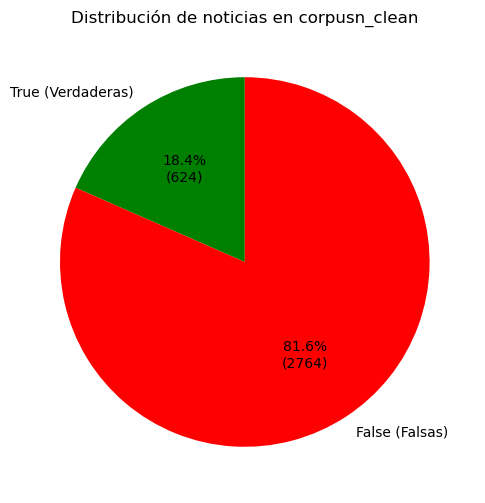

In [40]:
import matplotlib.pyplot as plt

# Conteo de noticias verdaderas y falsas
counts = corpusn_clean["Category"].value_counts()

# Reordenar para que siempre sea [True, False]
counts = counts.reindex([True, False])

# Imprimir cantidades
print("Cantidad de noticias verdaderas (True):", counts.get(True, 0))
print("Cantidad de noticias falsas (False):", counts.get(False, 0))
print(f"Cantidad de noticias totales: {len(corpusn_clean)}")

# Función para mostrar porcentaje y cantidad
def autopct_format(pct, allvals):
    absolute = int(round(pct/100.*sum(allvals)))
    return f"{pct:.1f}%\n({absolute})"

# Gráfico de torta con porcentajes y cantidades
plt.figure(figsize=(6,6))
plt.pie(
    counts,
    labels=["True (Verdaderas)", "False (Falsas)"],
    autopct=lambda pct: autopct_format(pct, counts),
    colors=["green", "red"],
    startangle=90
)
plt.title("Distribución de noticias en corpusn_clean")

# Guardar imagen en PNG
plt.savefig("distribucion_corpusn_clean.png", dpi=300)

plt.show()


In [41]:
import sys
print(sys.executable)


C:\Users\lendg\anaconda3\python.exe


In [42]:
from sklearn.model_selection import train_test_split

# Separar features y etiquetas
X = corpusn_clean.drop(columns=["Category"])
y = corpusn_clean["Category"]

# División train/test manteniendo proporciones originales (estratificación)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,          # 80/20
    random_state=42,
    stratify=y              # mantiene proporción de clases
)

# Reconstruir dataframes finales
train = X_train.copy()
train["Category"] = y_train

test = X_test.copy()
test["Category"] = y_test

# Verificar tamaños y balance
print("Train size:", len(train))
print("Test size:", len(test))
print("Train balance:\n", train["Category"].value_counts(normalize=True))
print("Test balance:\n", test["Category"].value_counts(normalize=True))


Train size: 2710
Test size: 678
Train balance:
 Category
False    0.815867
True     0.184133
Name: proportion, dtype: float64
Test balance:
 Category
False    0.815634
True     0.184366
Name: proportion, dtype: float64


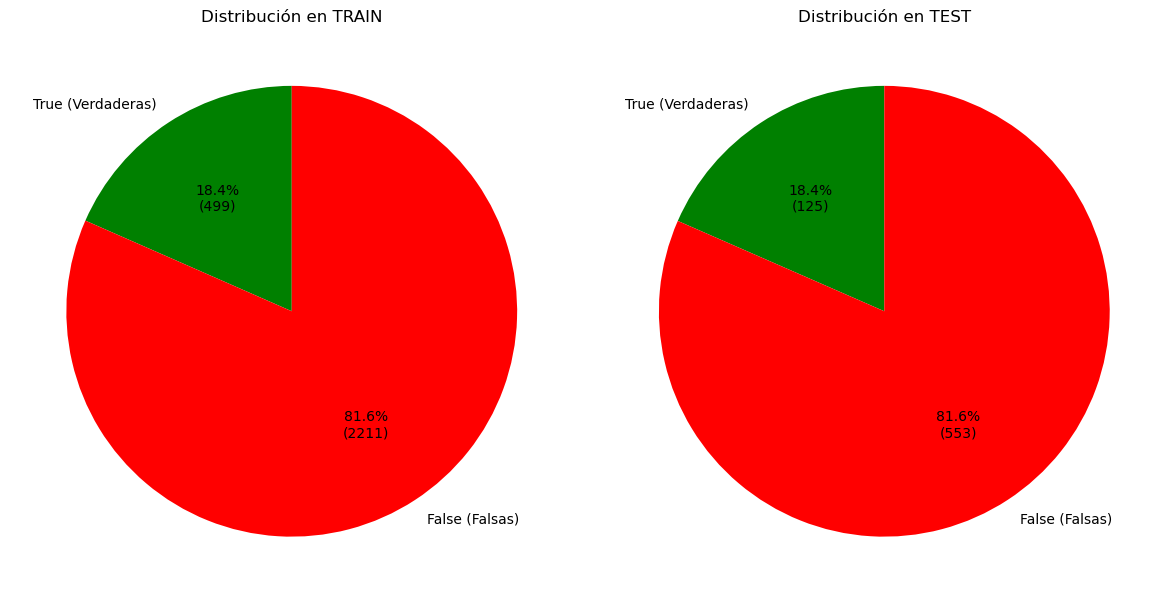

In [46]:
import matplotlib.pyplot as plt

# Conteo de categorías en train y test, reordenados
train_counts = train["Category"].value_counts().reindex([True, False])
test_counts = test["Category"].value_counts().reindex([True, False])

# Crear figura con dos subplots lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12,6))

# Gráfico de torta para TRAIN
axes[0].pie(
    train_counts,
    labels=["True (Verdaderas)", "False (Falsas)"],
    autopct=lambda pct: f"{pct:.1f}%\n({int(round(pct/100.*sum(train_counts)))})",
    colors=["green", "red"],
    startangle=90
)
axes[0].set_title("Distribución en TRAIN")

# Gráfico de torta para TEST
axes[1].pie(
    test_counts,
    labels=["True (Verdaderas)", "False (Falsas)"],
    autopct=lambda pct: f"{pct:.1f}%\n({int(round(pct/100.*sum(test_counts)))})",
    colors=["green", "red"],
    startangle=90
)
axes[1].set_title("Distribución en TEST")

# Ajustar diseño
plt.tight_layout()

# Guardar imagen en PNG
plt.savefig("balance_train_test.png", dpi=300)

# Mostrar gráficos
plt.show()


In [47]:
print("\n=== train_final ===")
print(train.info())
print("\n=== test_final ===")
print(test.info())


=== train_final ===
<class 'pandas.core.frame.DataFrame'>
Index: 2710 entries, 2795 to 2691
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Topic          2710 non-null   object
 1   Source         2331 non-null   object
 2   Headline       1473 non-null   object
 3   Text           2710 non-null   object
 4   Link           1859 non-null   object
 5   Headline_Text  2710 non-null   object
 6   Text_length    2710 non-null   int64 
 7   Category       2710 non-null   bool  
dtypes: bool(1), int64(1), object(6)
memory usage: 172.0+ KB
None

=== test_final ===
<class 'pandas.core.frame.DataFrame'>
Index: 678 entries, 2297 to 2068
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Topic          678 non-null    object
 1   Source         598 non-null    object
 2   Headline       374 non-null    object
 3   Text           678 non-null    objec

In [48]:
# Guardar dataset limpio en CSV con codificación segura
train.to_csv("train_final.csv", index=False, encoding="utf-8", quoting=csv.QUOTE_MINIMAL)  # quoting=1 equivale a QUOTE_ALL
test.to_csv("test_final.csv", index=False, encoding="utf-8", quoting=csv.QUOTE_MINIMAL)
